In [ ]:
# Download Dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "adiithape1/plant-disease-detection-dataset-master-version"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'plant-disease-detection-dataset-master-version' dataset.
Dataset path: /kaggle/input/plant-disease-detection-dataset-master-version


In [ ]:
# Load Libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Set Dataset Path
import os

for root, dirs, files in os.walk(path):
    print(root)
    break

dataset_dir = path  # or path + "/PlantVillage"

/kaggle/input/plant-disease-detection-dataset-master-version


In [ ]:
# Image Preprocessing
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 115109 images belonging to 1 classes.
Found 28777 images belonging to 1 classes.


In [ ]:
# Build FAST MODEL
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze for speed

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Full Model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5   # keep small for CPU training
)

Epoch 1/5
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 1121s 310ms/step - accuracy: 1.0000 - loss: 8.7181e-05 - val_accuracy: 1.0000 - val_loss: 8.9960e-11
Epoch 2/5
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 1149s 319ms/step - accuracy: 1.0000 - loss: 5.4008e-10 - val_accuracy: 1.0000 - val_loss: 7.4269e-11
Epoch 3/5
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 1113s 309ms/step - accuracy: 1.0000 - loss: 4.3611e-10 - val_accuracy: 1.0000 - val_loss: 4.9305e-11
Epoch 4/5
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 1119s 311ms/step - accuracy: 1.0000 - loss: 3.4436e-10 - val_accuracy: 1.0000 - val_loss: 2.3255e-11
Epoch 5/5
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 1131s 314ms/step - accuracy: 1.0000 - loss: 1.5047e-10 - val_accuracy: 1.0000 - val_loss: 1.0897e-11


In [ ]:
# Evaluate Model
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

900/900 ━━━━━━━━━━━━━━━━━━━━ 226s 251ms/step - accuracy: 1.0000 - loss: 1.0897e-11
Validation Accuracy: 1.0


In [ ]:
# Save Model
model.save("leaf_disease_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
# Predict Single Image
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        print("❌ Infected Leaf")
    else:
        print("✅ Healthy Leaf")

In [ ]:
# Cleanup Prediction cell
import os

test_dir = os.path.join(path, "MasterDataset", "test")

sample_image = None

for root, dirs, files in os.walk(test_dir):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            sample_image = os.path.join(root, file)
            break
    if sample_image:
        break

predict_image(sample_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
✅ Healthy Leaf


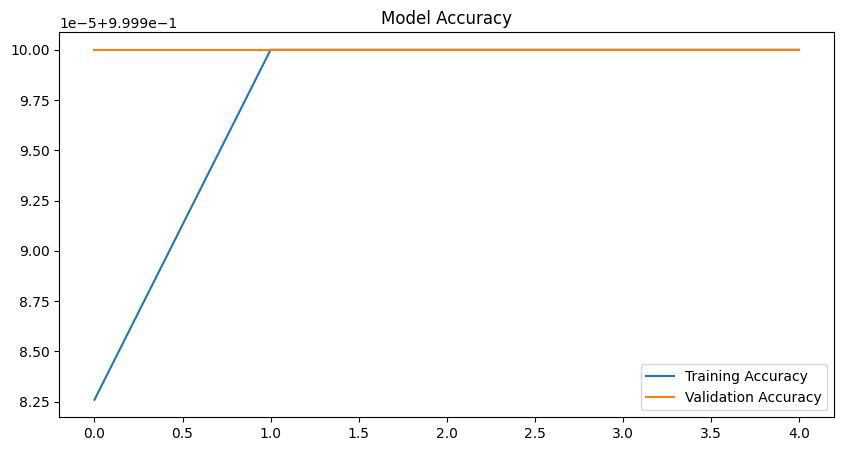

In [ ]:
# Accuracy/Loss Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

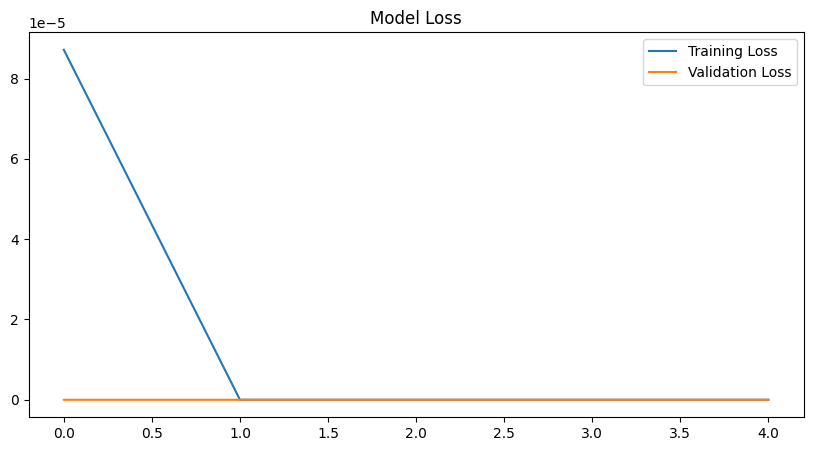

In [ ]:
# Loss Graph
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()